# 02 - Data Preprocessing Pipeline

TODO: fill in this notebook.

In [1]:
import sys
sys.path.append('../src')

# TODO: your imports here


In [1]:
import shutil
import random
from pathlib import Path

random.seed(42)  # ensures same split every time you run this

raw_dir = Path("../data/raw")
processed_dir = Path("../data/processed")

split_ratio = 0.8  # 80% train, 20% validation

for class_folder in ["Real Notes", "Fake Notes"]:
    images = list((raw_dir / class_folder).glob("*.*"))
    random.shuffle(images)

    split_point = int(len(images) * split_ratio)
    train_images = images[:split_point]
    val_images = images[split_point:]

    # Create destination folders
    (processed_dir / "train" / class_folder).mkdir(parents=True, exist_ok=True)
    (processed_dir / "val" / class_folder).mkdir(parents=True, exist_ok=True)

    # Copy files
    for img in train_images:
        shutil.copy(img, processed_dir / "train" / class_folder / img.name)
    for img in val_images:
        shutil.copy(img, processed_dir / "val" / class_folder / img.name)



    print(f"{class_folder}: {len(train_images)} train, {len(val_images)} val")

Real Notes: 760 train, 190 val
Fake Notes: 520 train, 130 val


In [3]:
import os

for split in ["train", "val"]:
    for class_folder in ["Real Notes", "Fake Notes"]:
        path = processed_dir / split / class_folder
        count = len(os.listdir(path))
        print(f"{split}/{class_folder}: {count} files")

train/Real Notes: 760 files
train/Fake Notes: 520 files
val/Real Notes: 190 files
val/Fake Notes: 130 files


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
)

val_datagen = ImageDataGenerator(rescale=1.0/255)  # no augmentation on validation data

train_generator = train_datagen.flow_from_directory(
    processed_dir / "train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True,
)

val_generator = val_datagen.flow_from_directory(
    processed_dir / "val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False,
)

print(train_generator.class_indices)

Found 1280 images belonging to 2 classes.
Found 320 images belonging to 2 classes.
{'Fake Notes': 0, 'Real Notes': 1}


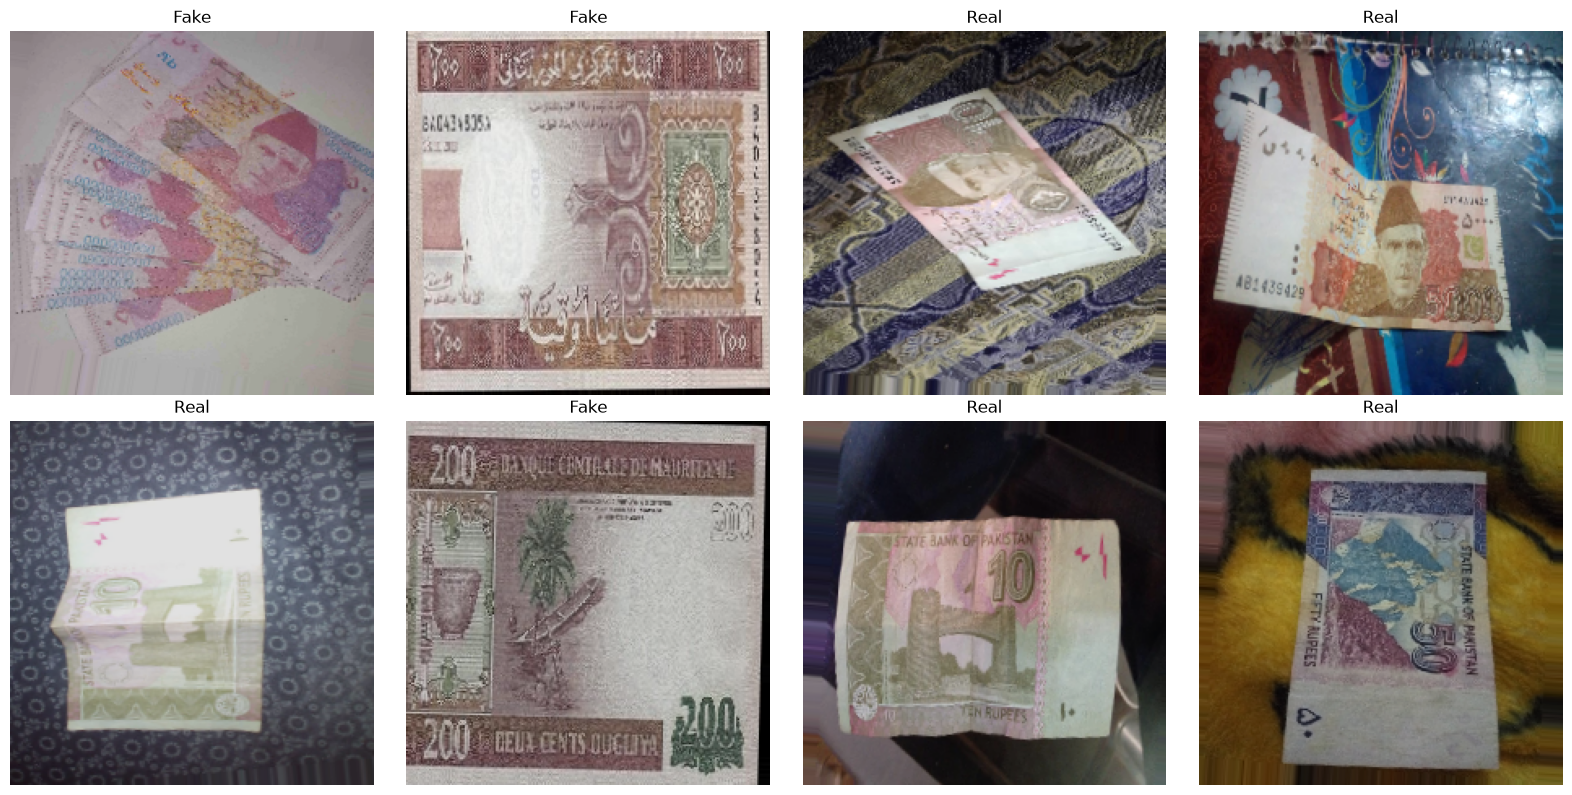

In [5]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    label = "Real" if labels[i] == 1 else "Fake"
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()